# Aprendizado Supervisionado

Neste notebook vamos ver o **basico** de aprendizado supervisionado, usando as noticias que ja foram transformadas em vetores (TF-IDF) no notebook de PLN.

A ideia geral do supervisionado e:

1. Temos um conjunto de exemplos `(X, y)`, onde `X` sao as variaveis de entrada (*features*) e `y` e o que queremos prever (*alvo*).
2. Separamos os dados em **treino** e **teste**.
3. Treinamos o modelo no **treino**.
4. Usamos o parametro OOB
5. Avaliamos o desempenho final no **teste**, que o modelo nunca viu.



- **Classificacao**: prever se uma noticia tem no texto 'esporte' (sim / nao).

As *features* serao as colunas do TF-IDF.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    r2_score,
)

## Carregando os dados

Usamos o `tfidf.csv` (matriz TF-IDF + metadados) e o `noticias.csv` (texto original e tags).

In [2]:
df = pd.read_csv("dados/df_final_tfidf.csv")

print("TF-IDF:", df.shape)
df.head(2)

C:\Users\mjlia\AppData\Local\Temp\ipykernel_20404\2275984538.py:1: DtypeWarning: Columns (0: tags) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dados/df_final_tfidf.csv")


TF-IDF: (333, 18608)


,Unnamed: 0,data,tags,titulo,url,texto,tfidf_00,tfidf_000,tfidf_00024,tfidf_0009,...,tfidf_zona,tfidf_zonas,tfidf_zone,tfidf_zones,tfidf_zoologicos,tfidf_zotto,tfidf_zov6pfqais,tfidf_zozelw8n8a,tfidf_zuerlein,tfidf_zvi
0,0,Sem data,NaN,Tati Weston-Webb vence número um do mundo no s...,https://exame.com/esporte/tati-weston-webb-ven...,Surfe feminino: veja quem se classificou para ...,0.073763,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,Sem data,NaN,Olimpíadas de Inverno: hoje tem Brasil no Bobs...,https://exame.com/esporte/olimpiadas-de-invern...,Edson Luques Bindilatti e Luis Bacca Gonçalves...,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Montando X (features)

Pegamos so as colunas que comecam com `tfidf_` para formar a matriz `X`.

In [3]:
colunas_tfidf = [c for c in df.columns if c.startswith("tfidf_")]
X = df[colunas_tfidf].values
print("X:", X.shape)

X: (333, 18602)


## 1) Classificacao - a noticia fala de Esporte?

A coluna `texto`. Vamos criar um alvo binario `y` que vale `1` quando o texto aparece 'esporte' aparece e `0` caso contrario.

In [6]:
y = df["texto"].fillna("").str.contains("esporte").astype(int).values

# print("Distribuicao das classes:")
# print(pd.Series(y).value_counts())
# # print(f"  0 - Sem esporte: {(y == 0).sum()}")
# # print(f"  1 - Com esporte: {(y == 1).sum()}")

In [7]:
print(f"\nFeatures (X): {len(colunas_tfidf)} palavras no vocabulário TF-IDF")
 
print(f"\nAlvo (y) — A notícia fala de esporte?")
print(f"  0 - Não fala de esporte: {(y == 0).sum()} notícias ({(y == 0).mean()*100:.1f}%)")
print(f"  1 - Fala de esporte:     {(y == 1).sum()} notícias ({(y == 1).mean()*100:.1f}%)")


Features (X): 18602 palavras no vocabulário TF-IDF

Alvo (y) — A notícia fala de esporte?
  0 - Não fala de esporte: 180 notícias (54.1%)
  1 - Fala de esporte:     153 notícias (45.9%)


### Separando treino / teste (80% / 20%)
Com OOB Score, não precisamos de um conjunto de calibração separado.
O OOB já faz esse papel internamente.
Por isso a divisão aqui é só TREINO e TESTE.


Com n=333, os tamanhos ficam:

1. Treino: ~266 notícias (80%)
2. Teste:  ~67  notícias (20%)

<!-- Vamos usar aproximadamente **60% treino, 20% calibracao, 20% teste**. Fazemos isso em duas etapas com `train_test_split`:

1. Separamos 20% para teste.
2. Dos 80% restantes, separamos 25% para calibracao (que corresponde a 20% do total).

Usamos `stratify=y_clf` para manter a proporcao das classes em cada subconjunto. -->

In [9]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,      # 20% vai para teste
    random_state=42,    # semente para reprodutibilidade
    stratify=y          # mantém proporção das classes
)
 
print(f"\nDivisão dos dados (n=333):")
print(f"  Treino: {X_treino.shape[0]} notícias ({X_treino.shape[0]/len(X)*100:.0f}%)")
print(f"  Teste:  {X_teste.shape[0]} notícias ({X_teste.shape[0]/len(X)*100:.0f}%)")
 


Divisão dos dados (n=333):
  Treino: 266 notícias (80%)
  Teste:  67 notícias (20%)


Calibração com OOB

In [10]:
opcoes_arvores = [10, 50, 100, 200, 300, 500]
resultados = []
 
print("\nCalibrando com OOB Score...")
print("-" * 50)
 
for n in opcoes_arvores:
    modelo = RandomForestClassifier(
        n_estimators=n,   # número de árvores na floresta
        oob_score=True,   # ativa o cálculo do OOB Score
        random_state=42,
        n_jobs=-1         # usa todos os núcleos do processador
    )
    modelo.fit(X_treino, y_treino)   # treina com TODOS os dados de treino
 
    oob = modelo.oob_score_          # acurácia estimada pelo OOB (sem usar o teste)
    resultados.append({"n_estimators": n, "oob_score": round(oob, 4)})
    print(f"  {n:>4} árvores → OOB Score: {oob:.4f}")
 
df_oob = pd.DataFrame(resultados)
 
# Escolhe o n_estimators com maior OOB Score
melhor_n = int(df_oob.loc[df_oob["oob_score"].idxmax(), "n_estimators"])
print(f"\nMelhor número de árvores pelo OOB Score: {melhor_n}")
 


Calibrando com OOB Score...
--------------------------------------------------
    10 árvores → OOB Score: 0.7293
    50 árvores → OOB Score: 0.6880
   100 árvores → OOB Score: 0.7669
   200 árvores → OOB Score: 0.7820
   300 árvores → OOB Score: 0.7744
   500 árvores → OOB Score: 0.7820

Melhor número de árvores pelo OOB Score: 200


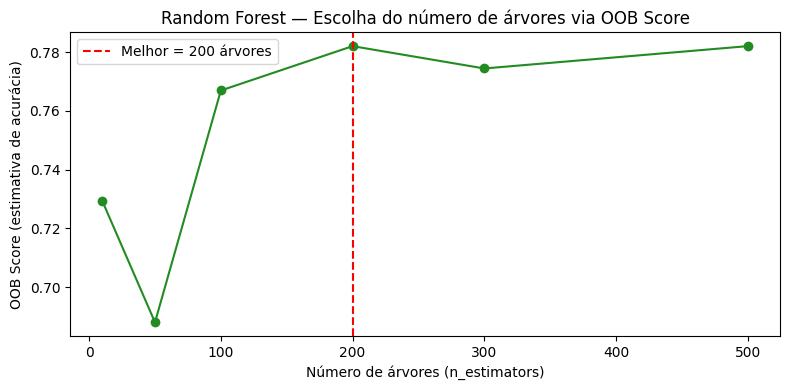

 n_estimators  oob_score
           10     0.7293
           50     0.6880
          100     0.7669
          200     0.7820
          300     0.7744
          500     0.7820


In [13]:
# Gráfico: OOB Score por número de árvores
plt.figure(figsize=(8, 4))
plt.plot(df_oob["n_estimators"], df_oob["oob_score"], marker="o", color="forestgreen")
plt.axvline(melhor_n, color="red", linestyle="--", label=f"Melhor = {melhor_n} árvores")
plt.xlabel("Número de árvores (n_estimators)")
plt.ylabel("OOB Score (estimativa de acurácia)")
plt.title("Random Forest — Escolha do número de árvores via OOB Score")
plt.legend()
plt.tight_layout()
plt.show()
 
print(df_oob.to_string(index=False))

In [11]:
modelo_final = RandomForestClassifier(
    n_estimators=melhor_n,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
modelo_final.fit(X_treino, y_treino)
 
print(f"\nModelo final treinado com {melhor_n} árvores!")
print(f"OOB Score estimado (antes do teste): {modelo_final.oob_score_:.4f}")


Modelo final treinado com 200 árvores!
OOB Score estimado (antes do teste): 0.7820


In [12]:
pred_teste = modelo_final.predict(X_teste)
 
acc  = accuracy_score(y_teste, pred_teste)
prec = precision_score(y_teste, pred_teste, zero_division=0)
rec  = recall_score(y_teste, pred_teste, zero_division=0)
f1   = f1_score(y_teste, pred_teste, zero_division=0)
 
print("\n" + "="*55)
print("RESULTADO FINAL — CONJUNTO DE TESTE")
print("="*55)
print(f"  OOB Score (estimativa treino): {modelo_final.oob_score_:.3f}")
print(f"  Acurácia  (teste real):        {acc:.3f}")
print(f"  → Se OOB ≈ Acurácia: modelo generalizou bem!")
print(f"  → Se OOB >> Acurácia: modelo pode ter sofrido overfitting")
print()
print(f"  Precisão:  {prec:.3f} → quando diz 'tem esporte', acerta {prec*100:.1f}% das vezes")
print(f"  Recall:    {rec:.3f}  → encontra {rec*100:.1f}% das notícias de esporte")
print(f"  F1-score:  {f1:.3f}  → equilíbrio entre precisão e recall")
 
print("\nRelatório completo por classe:")
print(classification_report(
    y_teste, pred_teste,
    target_names=["Sem esporte", "Com esporte"]
))
 


RESULTADO FINAL — CONJUNTO DE TESTE
  OOB Score (estimativa treino): 0.782
  Acurácia  (teste real):        0.881
  → Se OOB ≈ Acurácia: modelo generalizou bem!
  → Se OOB >> Acurácia: modelo pode ter sofrido overfitting

  Precisão:  0.926 → quando diz 'tem esporte', acerta 92.6% das vezes
  Recall:    0.806  → encontra 80.6% das notícias de esporte
  F1-score:  0.862  → equilíbrio entre precisão e recall

Relatório completo por classe:
              precision    recall  f1-score   support

 Sem esporte       0.85      0.94      0.89        36
 Com esporte       0.93      0.81      0.86        31

    accuracy                           0.88        67
   macro avg       0.89      0.88      0.88        67
weighted avg       0.89      0.88      0.88        67



matriz de confusão

Matriz de Confusão (linhas=real, colunas=previsto):
             Sem esporte  Com esporte
Sem esporte           34            2
Com esporte            6           25


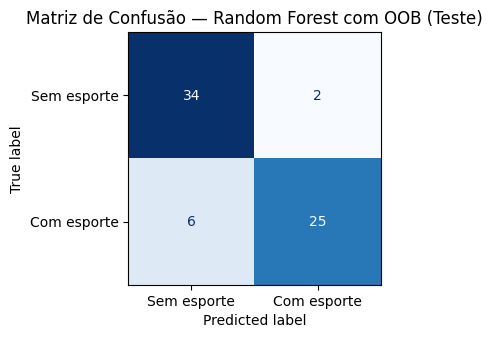

In [13]:
cm = confusion_matrix(y_teste, pred_teste)
 
print("Matriz de Confusão (linhas=real, colunas=previsto):")
print(pd.DataFrame(
    cm,
    index=["Sem esporte", "Com esporte"],
    columns=["Sem esporte", "Com esporte"]
))
 
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Sem esporte", "Com esporte"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
plt.title("Matriz de Confusão — Random Forest com OOB (Teste)")
plt.tight_layout()
plt.show()

In [16]:

# importancias = modelo_final.feature_importances_
# df_imp = pd.DataFrame({
#     "palavra": [c.replace("tfidf_", "") for c in colunas_tfidf],
#     "importancia": importancias
# })
# df_imp = df_imp.sort_values("importancia", ascending=False).head(10)
 
# print("\nTop 15 palavras mais importantes para detectar 'esporte':")
# print(df_imp.to_string(index=False))
 
# plt.figure(figsize=(9, 5))
# plt.barh(df_imp["palavra"][::-1], df_imp["importancia"][::-1], color="forestgreen")
# plt.xlabel("Importância")
# plt.title("Random Forest — Palavras mais relevantes para detectar 'esporte'")
# plt.tight_layout()
# plt.show()

In [17]:
# df = pd.read_csv("dados/dados_olimpiadas_exame.csv")

In [22]:
# print(df["tags"].value_counts().head(20))

In [21]:
# print("Total de linhas:", len(df))
# print("Com tag:        ", df["tags"].notna().sum())
# print("Sem tag:        ", df["tags"].isna().sum())
# print("\nTags mais comuns:")
# print(df["tags"].value_counts().head(20))